# Train  a new classifier for CoastSat

In this notebook the CoastSat classifier is trained using satellite images from new sites. This can improve the accuracy of the shoreline detection if the users are experiencing issues with the default classifier.

#### Initial settings

In [15]:
# load modules
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import sklearn
if sklearn.__version__[:4] == '0.20':
    from sklearn.externals import joblib
else:
    import joblib

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_classify

# plotting params
plt.rcParams['font.size'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 12

# filepaths 
filepath_images = os.path.join(os.getcwd(), 'data')
filepath_train = os.path.join(os.getcwd(), 'training_data')
filepath_models = os.path.join(os.getcwd(), 'models')

# settings for 5-CLASS CLASSIFIER (WITH ROCK CLASS)
settings ={'filepath_train':filepath_train, # folder where the labelled images will be stored
           'cloud_thresh':0.9, # percentage of cloudy pixels accepted on the image
           'cloud_mask_issue':True, # set to True if problems with the default cloud mask
           'pan_off': False, # set to True to disable pan-sharpening
           'inputs':{'filepath':filepath_images}, # folder where the images are stored
           # 5 CLASSES - Including ROCK (label = 4)
           'labels':{'sand':1,'white-water':2,'water':3,'rock':4,'other land features':0}, # labels for the classifier
           'colors':{'sand':[1, 0.65, 0],'white-water':[1,0,1],'water':[0.1,0.1,0.7],
                     'rock':[0.55, 0.27, 0.07],'other land features':[0.8,0.8,0.1]},  # rock = brown
           'tolerance':0.01, # this is the pixel intensity tolerance, when using flood fill for sandy pixels, set to 0 to select one pixel at a time
            's2cloudless_prob': 60,     # probability threshold to identify cloudy pixels in the s2cloudless mask
            }
        
# read kml files for the training sites
filepath_sites = os.path.join(os.getcwd(), 'training_sites')
train_sites = os.listdir(filepath_sites)
print('Sites for training:\n%s\n'%train_sites)
# ROCKY COASTLINE SITES (France) - for training rock class
#train_sites_rocky = ['CRIEL.kml','BIARRITZ.kml','CASSIS.kml']

# Use rocky sites for training
#train_sites = train_sites_rocky
#print('Rocky sites for training:\n%s\n'%train_sites)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Sites for training:
['BYRON.kml', 'NEWCASTLE.kml', 'SAWTELL.kml']



### 1. Download images

For each site on which you want to train the classifier, save a .kml file with the region of interest (5 vertices clockwise, first and last points are the same, can be created from Google myMaps) in the folder *\training_sites*.

You only need a few images (~10) to train the classifier.

In [ ]:
# # authenticate GEE with project name (YOU NEED TO INPUT YOUR OWN PROJECT NAME)
# project_name = 'coastai123'
# SDS_download.authenticate_and_initialize(project_name)
# # dowload images at the sites
# dates = ['2019-01-01', '2019-07-01']
# sat_list = ['S2']
# collection = 'C02'
# for site in train_sites:
#     polygon = SDS_tools.polygon_from_kml(os.path.join(filepath_sites,site))
#     polygon = SDS_tools.smallest_rectangle(polygon)
#     sitename = site[:site.find('.')]
#     inputs = {'polygon':polygon, 'dates':dates, 'sat_list':sat_list,
#              'sitename':sitename, 'filepath':filepath_images}
#     print(sitename)
#     metadata = SDS_download.retrieve_images(inputs)

GEE initialized (existing token).
BYRON
Number of images available between 2019-01-01 and 2019-07-01:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     S2: 36 images
  Total to download: 36 images

S2: 36 images
100%
Satellite images downloaded from GEE and save in c:\Users\bamba\COAST_AI\CoastSat\classification\data\BYRON
NEWCASTLE
Number of images available between 2019-01-01 and 2019-07-01:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     S2: 68 images
  Total to download: 68 images

S2: 68 images
100%
Satellite images downloaded from GEE and save in c:\Users\bamba\COAST_AI\CoastSat\classification\data\NEWCASTLE
SAWTELL
Number of images available between 2019-01-01 and 2019-07-01:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     S2: 70 images
  Total to download: 70 images

S2: 70 images
100%
Satellite images downloaded from GEE and save in c:\Users\bamba\COAST_AI\CoastSat\classification\data\SAWTELL


In [17]:
# authenticate GEE with project name (YOU NEED TO INPUT YOUR OWN PROJECT NAME)
project_name = 'coastai123'
SDS_download.authenticate_and_initialize(project_name)
# dowload images at the sites
dates = ['2019-01-01', '2019-07-01']
sat_list = ['S2']
#collection = 'C02'
# put the coordonates of thetraining site if .kml don't work
polygon = [[[1.3183427681049409,50.037424689004325],[1.319964348068396,50.03687068586123],
            [1.3248980913650428,50.04052698847573],[1.327520220668191,50.04300868372172],
            [1.3307633805972898,50.04564534435033],[1.3285552717099165,50.04679745310412],
            [1.3242425590382254,50.042321798770814],[1.3203438667843557,50.038776429846024],
            [1.3183427681049409,50.037424689004325]]]
#put the same polygon's name site
sitename = 'CRIEL'
inputs = {'polygon':polygon, 'dates':dates, 'sat_list':sat_list,
        'sitename':sitename, 'filepath':filepath_images}
print(sitename)
metadata = SDS_download.retrieve_images(inputs)

GEE initialized (existing token).
CRIEL
Number of images available between 2019-01-01 and 2019-07-01:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     S2: 27 images
  Total to download: 27 images
S2: 10/27 images already exist, 17 to be downloaded

S2: 17 images
100%
Satellite images downloaded from GEE and save in c:\Users\bamba\COAST_AI\CoastSat\classification\data\CRIEL


### 2. Label images

Label the images into 5 classes: sand, white-water, water, rock and other land features.

The labelled images are saved in the *filepath_train* and can be visualised afterwards for quality control. If yo make a mistake, don't worry, this can be fixed later by deleting the labelled image.

In [ ]:
# # label the images with an interactive annotator
# %matplotlib qt
# #settings['inputs']['landsat_collection'] = collection
# for site in train_sites:
#     settings['inputs']['sitename'] = site[:site.find('.')]
#     # load metadata
#     metadata = SDS_download.get_metadata(settings['inputs'])
#     # label images
#     SDS_classify.label_images(metadata,settings)

In [18]:
# label the images with an interactive annotator
%matplotlib qt
#settings['inputs']['landsat_collection'] = collection
settings['inputs']['sitename'] = sitename
# load metadata
metadata = SDS_download.get_metadata(settings['inputs'])
# label images
SDS_classify.label_images(metadata,settings)

### 3. Train Classifier

A Multilayer Perceptron is trained with *scikit-learn*. To train the classifier, the training data needs to be loaded.

You can use the data that was labelled here and/or the original CoastSat training data.

In [19]:
# load labelled images
features = SDS_classify.load_labels(train_sites, settings)

Number of pixels per class in training data:
sand : 2828 pixels
white-water : 581 pixels
water : 26490 pixels
rock : 5296 pixels
other land features : 274775 pixels


In [ ]:
# you can also load the original CoastSat training data (and optionally merge it with your labelled data)
#with open(os.path.join(settings['filepath_train'], 'CoastSat_training_set_L8.pkl'), 'rb') as f:
with open(os.path.join(settings['filepath_train'], 'CoastSat_training_set_L8.pkl'), 'rb') as f:
    features_original = pickle.load(f)
for key in features_original.keys():
    print('%s : %d pixels'%(key,len(features_original[key])))

sand : 4842 pixels
water : 51920 pixels
white-water : 2142 pixels
other land features : 120045 pixels


In [59]:
def convert_20_to_24_features(data_20):
    """Convert 20-feature data to 24-feature format by inserting zeros for RI, BSI indices"""
    n_samples = data_20.shape[0]
    data_24 = np.zeros((n_samples, 24))
    # Copy first 10 features (5 bands + NDWI, NDVI, MNDWI, Brightness, NDBI)
    data_24[:, 0:10] = data_20[:, 0:10]
    # Skip positions 10,11 (RI, BSI) - leave as zeros
    # Copy next 10 features (5 std_bands + 5 std_indices) to positions 12-21
    data_24[:, 12:22] = data_20[:, 10:20]
    # Skip positions 22,23 (std_RI, std_BSI) - leave as zeros
    return data_24

# Convert original features from 20 to 24 dimensions
for key in features_original.keys():
    if features_original[key].shape[1] == 20:
        features_original[key] = convert_20_to_24_features(features_original[key])
        print('%s converted to 24 features'%key)


sand converted to 24 features
water converted to 24 features
white-water converted to 24 features
other land features converted to 24 features


Run this section to combine the original training data with your labelled data:

In [60]:
# merge all the classes (except 'rock' which doesn't exist in original data)
for key in features.keys():
    if key in features_original and key != 'rock':
        features[key] = np.append(features[key], features_original[key], axis=0)
#features = features_original
for key in features.keys():
    print('%s : %d pixels'%(key,len(features[key])))

sand : 7670 pixels
white-water : 2723 pixels
water : 78410 pixels
rock : 5296 pixels
other land features : 394820 pixels


In [42]:
# # add the white-water data from the original training data
# # features['white-water'] = np.append(features['white-water'], features_original['white-water'], axis=0)
# # or merge all the classes
# for key in features.keys():
#     features[key] = np.append(features[key], features_original[key], axis=0)
# #features = features_original
# for key in features.keys():
#     print('%s : %d pixels'%(key,len(features[key])))

[OPTIONAL] As the classes do not have the same number of pixels, it is good practice to subsample the very large classes (in this case 'water' and 'other land features'):

In [20]:
# subsample randomly the land and water classes
# as the most important class is 'sand', the number of samples should be close to the number of sand pixels
n_samples = 5000
for key in ['water', 'other land features']:
    if len(features[key]) > n_samples:
        features[key] = features[key][np.random.choice(features[key].shape[0], n_samples, replace=False),:]
# print classes again
for key in features.keys():
    print('%s : %d pixels'%(key,len(features[key])))

sand : 2828 pixels
white-water : 581 pixels
water : 5000 pixels
rock : 5296 pixels
other land features : 5000 pixels


When the labelled data is ready, format it into X, a matrix of features, and y, a vector of labels:

In [21]:
# format into X (features) and y (labels) 
# 5 CLASSES: sand=1, white-water=2, water=3, rock=4, other=0
classes = ['sand','white-water','water','rock','other land features']
labels = [1,2,3,4,0]
X,y = SDS_classify.format_training_data(features, classes, labels)

Divide the dataset into train and test: train on 70% of the data and evaluate on the other 30%:

In [22]:
# Nettoyer les données : remplacer inf et valeurs trop grandes
import numpy as np

# Vérifier les problèmes dans X
print(f"Shape of X: {X.shape}")
print(f"NaN values: {np.isnan(X).sum()}")
print(f"Inf values: {np.isinf(X).sum()}")
print(f"Max value: {np.nanmax(X[~np.isinf(X)])}")
print(f"Min value: {np.nanmin(X[~np.isinf(X)])}")

# Remplacer les inf par nan, puis les nan par 0
X = np.where(np.isinf(X), np.nan, X)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Vérifier après nettoyage
print(f"\nAfter cleaning:")
print(f"NaN values: {np.isnan(X).sum()}")
print(f"Inf values: {np.isinf(X).sum()}")

Shape of X: (18705, 24)
NaN values: 0
Inf values: 8
Max value: 0.7872795296632816
Min value: -0.9475524475524475

After cleaning:
NaN values: 0
Inf values: 0


In [23]:
# divide in train and test and evaluate the classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=0)
classifier = MLPClassifier(hidden_layer_sizes=(100,50), solver='adam')
classifier.fit(X_train,y_train)
print('Accuracy: %0.4f' % classifier.score(X_test,y_test))

Accuracy: 0.8550


[OPTIONAL] A more robust evaluation is 10-fold cross-validation (may take a few minutes to run):

In [ ]:
# # cross-validation
# scores = cross_val_score(classifier, X, y, cv=10)
# print('Accuracy: %0.4f (+/- %0.4f)' % (scores.mean(), scores.std() * 2))

Accuracy: 0.9063 (+/- 0.1646)


Plot a confusion matrix:

Confusion matrix, without normalization


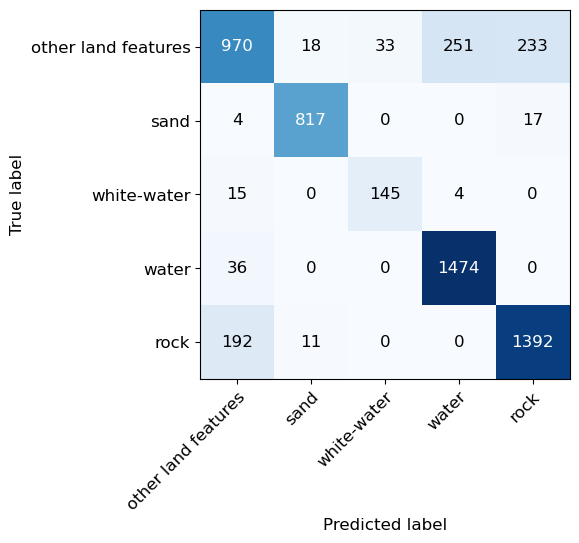

In [24]:
# plot confusion matrix
%matplotlib inline
y_pred = classifier.predict(X_test)
SDS_classify.plot_confusion_matrix(y_test, y_pred,
                                   classes=['other land features','sand','white-water','water', 'rock'],
                                   normalize=False);

When satisfied with the accuracy and confusion matrix, train the model using ALL the training data and save it:

In [25]:
# train with all the data and save the final classifier
# train with all the data and save the final 5-CLASS classifier
classifier = MLPClassifier(hidden_layer_sizes=(100,50), solver='adam')
classifier.fit(X,y)
#joblib.dump(classifier, os.path.join(filepath_models, 'NN_5classes_Landsat_rock.pkl'))
joblib.dump(classifier, os.path.join(filepath_models, 'NN_5classes_S2_rock.pkl'))
# Also save with _new suffix for sklearn version compatibility
#joblib.dump(classifier, os.path.join(filepath_models, 'NN_5classes_Landsat_rock_new.pkl'))
joblib.dump(classifier, os.path.join(filepath_models, 'NN_5classes_S2_rock_new.pkl'))
print('Classifier saved as: NN_5classes_S2_rock.pkl and NN_5classes_S2_rock_new.pkl')

Classifier saved as: NN_5classes_S2_rock.pkl and NN_5classes_S2_rock_new.pkl


### 4. Evaluate the classifier

Load a classifier that you have trained (specify the classifiers filename) and evaluate it on the satellite images.

This section will save the output of the classification for each site in a directory named \evaluation.

In [26]:
# load and evaluate a classifier
%matplotlib qt
classifier = joblib.load(os.path.join(filepath_models, 'NN_5classes_S2_rock.pkl'))
settings['output_epsg'] = 2154
settings['min_beach_area'] = 4500
settings['buffer_size'] = 200
settings['min_length_sl'] = 200
settings['cloud_thresh'] = 0.5
settings['dist_clouds'] = 100
#settings['inputs']['landsat_collection'] = 'C02'
# visualise the classified images
for site in train_sites:
    settings['inputs']['sitename'] = site[:site.find('.')]
    # load metadata
    metadata = SDS_download.get_metadata(settings['inputs'])
    # plot the classified images
    SDS_classify.evaluate_classifier(classifier,metadata,settings)

![BYRON2019-04-12-23-41-59](https://github.com/kvos/CoastSat/assets/7217258/4e8e88f3-e753-4089-82ae-88fff0525d6b)